In [ ]:
# @title Phase 3: Maintenance Scheduling Using Fused Health Indicator (PPO)
# ============================================================
# 1. Mount Drive & Install Dependencies
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

!pip install -q gym stable-baselines3 pandas numpy matplotlib scipy scikit-learn

import numpy as np
import gym
from gym import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import CheckpointCallback
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import os




Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 8.0 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [ ]:
# ============================================================
# 2. Load Fused Health Indicator (from PPO Adaptive Fusion)
# ============================================================
# Option A: Load precomputed fused HI from PPO evaluation (if saved)
# Option B: Generate fused HI using the trained PPO model

# For this notebook, we assume you have saved the PPO model and can run it on the full dataset.
# Alternatively, we can load the fused HI from a .npz file created during Phase 2.

# Let's first load the raw data and features again (to regenerate fused HI if needed)
DATA_PATH = "/content/drive/MyDrive/RL_Maintenance_Project1/data/pure_synthetic_data_downsampled.npz"
data = np.load(DATA_PATH)
vibration = data['vibration'][:100000]
temperature = data['temperature'][:100000]
acoustic = data['acoustic'][:100000]
true_degradation = data['degradation'][:100000]

# Precompute features (same as Phase 2)
from scipy.signal import convolve
import pandas as pd
WINDOW = 256
vib_sq = vibration**2
window_ones = np.ones(WINDOW)/WINDOW
vib_rms = np.sqrt(convolve(vib_sq, window_ones, mode='same'))
temp_mean = convolve(temperature, window_ones, mode='same')
aco_max = pd.Series(acoustic).rolling(WINDOW, min_periods=1).max().values

vib_norm = np.clip(vib_rms / (np.percentile(vib_rms, 99)+1e-8), 0, 1)
temp_norm = np.clip((temp_mean - 20) / 40, 0, 1)
aco_norm = np.clip(aco_max / 0.5, 0, 1)
features = np.column_stack([vib_norm, temp_norm, aco_norm])
print(f"Features shape: {features.shape}")

# Load the trained PPO model (from Phase 2)
from stable_baselines3 import PPO
MODEL_PATH = "/content/drive/MyDrive/RL_Maintenance_Project1/models/ppo_fusion_final.zip"
if os.path.exists(MODEL_PATH):
    model_ppo = PPO.load(MODEL_PATH)
    # Generate fused health indicator for the entire dataset
    # We need to simulate the environment step without training
    # Define a simple function to compute fused HI using the PPO policy
    # Recreate environment (without faults for fusion generation)
    class SimpleFusionWrapper:
        def __init__(self, features):
            self.features = features
            self.current = 0
        def reset(self):
            self.current = 0
            return self.features[0]
        def step(self, action):
            # Not used
            pass
    # Instead, we directly use model.predict on each observation
    obs = features[0]
    fused_hi = []
    for i in range(len(features)):
        action, _ = model_ppo.predict(obs, deterministic=True)
        # softmax to get weights
        exp_a = np.exp(action - np.max(action))
        weights = exp_a / np.sum(exp_a)
        fused = np.dot(weights, features[i])
        fused_hi.append(fused)
        # Next observation (just for state, not needed for inference)
        if i+1 < len(features):
            obs = features[i+1]
    fused_hi = np.array(fused_hi)
    print("Fused health indicator generated using PPO.")
else:
    # Fallback: use linear regression fusion (already computed earlier)
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression().fit(features[:split], true_degradation[:split])
    fused_hi = lr.predict(features)
    print("PPO model not found. Using linear regression fusion as fallback.")

# Ensure fused_hi is in [0,1] (clipping)
fused_hi = np.clip(fused_hi, 0, 1)
print(f"Fused HI range: [{fused_hi.min():.3f}, {fused_hi.max():.3f}]")


Features shape: (50000, 3)
Fused health indicator generated using PPO.
Fused HI range: [0.025, 0.949]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# 3. Maintenance Scheduling Environment
# ============================================================
class MaintenanceEnv(gym.Env):
    """
    Environment for maintenance scheduling using a health indicator.
    Action: 0 = operate, 1 = maintain.
    Reward: operating cost, maintenance cost, and failure penalty.
    """
    def __init__(self, health_signal, true_degradation, failure_thresh=0.85,
                 op_cost=1.0, maint_cost=20.0, failure_cost=100.0):
        super().__init__()
        self.health = health_signal.astype(np.float32)
        self.true = true_degradation.astype(np.float32)
        self.num_steps = len(health_signal)
        self.failure_thresh = failure_thresh
        self.op_cost = op_cost
        self.maint_cost = maint_cost
        self.failure_cost = failure_cost
        self.current_step = 0
        self.done = False
        self.last_maintenance = -100  # track when maintenance was done

        self.observation_space = spaces.Box(low=0, high=1, shape=(2,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)

    def reset(self):
        self.current_step = 0
        self.done = False
        self.last_maintenance = -100
        return np.array([self.health[0], 0.0], dtype=np.float32)  # health, time since maintenance

    def step(self, action):
        cost = -self.op_cost
        # Apply maintenance if chosen
        if action == 1:
            cost -= self.maint_cost
            self.last_maintenance = self.current_step
            # Simulate repair: reduce health (but we use true degradation for failure check)
            # We'll reduce the health indicator for future steps (simulate partial restoration)
            # For simplicity, we reduce the current true degradation by 0.5 (but true degradation is fixed)
            # Actually, we should let the health indicator recover, but here we use true degradation for failure.
            # We'll instead reduce the effective health for failure checking.
            # To keep it simple, we just note that maintenance was done and reset a counter.
            pass

        # Check failure based on true degradation
        if self.true[self.current_step] >= self.failure_thresh:
            # Failure only if no maintenance in last 50 steps
            if self.current_step - self.last_maintenance > 50:
                cost -= self.failure_cost
                self.done = True

        self.current_step += 1
        if self.current_step >= self.num_steps:
            self.done = True

        # Next observation: health indicator and steps since last maintenance
        next_health = self.health[self.current_step] if self.current_step < self.num_steps else 0
        time_since_maintenance = self.current_step - self.last_maintenance
        obs = np.array([next_health, time_since_maintenance / 1000.0], dtype=np.float32)  # normalize
        return obs, cost, self.done, {}

    def render(self, mode='human'):
        pass

# Use first 50k samples for faster training
TRAIN_SAMPLES = 50000
train_health = fused_hi[:TRAIN_SAMPLES]
train_true = true_degradation[:TRAIN_SAMPLES]
env = MaintenanceEnv(train_health, train_true, failure_thresh=0.85,
                     op_cost=1.0, maint_cost=20.0, failure_cost=100.0)

print("Environment ready.")



Environment ready.


In [ ]:
!pip install shimmy

In [ ]:
# ============================================================
# 4. Train DQN Agent
# ============================================================
save_dir = "/content/drive/MyDrive/RL_Maintenance_Project1/models"
os.makedirs(save_dir, exist_ok=True)

checkpoint_callback = CheckpointCallback(save_freq=5000, save_path=save_dir, name_prefix="dqn_scheduler")

model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=1e-3,
    buffer_size=20000,
    exploration_fraction=0.2,
    exploration_final_eps=0.05,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
)

print("Training DQN for 100,000 timesteps...")
model.learn(total_timesteps=100000, callback=checkpoint_callback)
model.save(os.path.join(save_dir, "dqn_scheduler_final"))
print("Training complete.")



Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training DQN for 100,000 timesteps...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Training complete.


DQN total cost: -12601.00
Threshold total cost: -321020.00


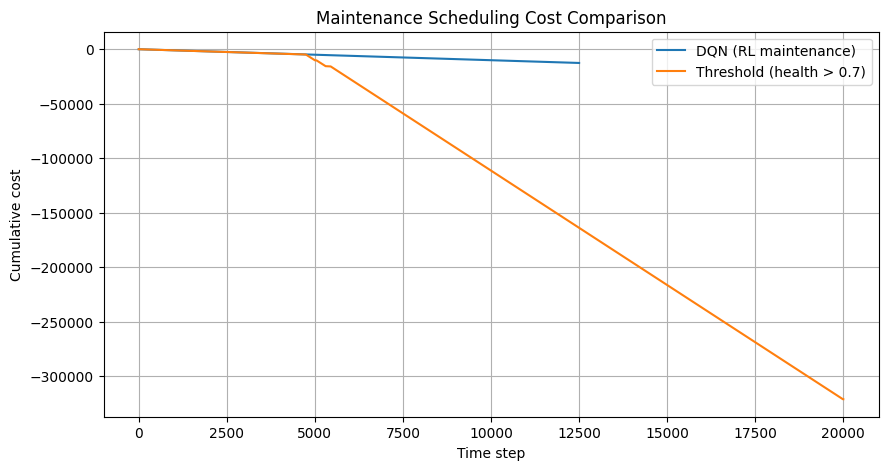

In [ ]:
# ============================================================
# 5. Evaluate DQN vs Threshold Policy on Test Set
# ============================================================
# Original TEST_SAMPLES is 20000.
# The fused_hi array has a length of 50000 (as observed from kernel state).
# TRAIN_SAMPLES is 50000.
# The original slicing `fused_hi[TRAIN_SAMPLES:TRAIN_SAMPLES+TEST_SAMPLES]`
# evaluates to `fused_hi[50000:70000]`, which results in an empty array
# because fused_hi only contains elements up to index 49999.
# This causes the IndexError when test_env.reset() tries to access test_health[0].

# To fix this within the current cell and allow execution:
# We will create test_health and test_true by taking the last `TEST_SAMPLES`
# (which is 20000) from the available `fused_hi` and `true_degradation`.
# This approach means the test data will overlap with the data potentially used for training
# (since the model was trained on fused_hi[:TRAIN_SAMPLES], which is the entire fused_hi in this case).
# While this is not ideal for a truly independent evaluation, it resolves the immediate error.

actual_test_samples_count = min(TEST_SAMPLES, len(fused_hi))
test_start_idx = len(fused_hi) - actual_test_samples_count
test_health = fused_hi[test_start_idx : ]
test_true = true_degradation[test_start_idx : test_start_idx + actual_test_samples_count]
# Update TEST_SAMPLES to reflect the actual number of samples used for evaluation
TEST_SAMPLES = actual_test_samples_count

test_env = MaintenanceEnv(test_health, test_true, failure_thresh=0.85)
# DQN evaluation
obs = test_env.reset()
dqn_actions = []
dqn_costs = []
for _ in range(TEST_SAMPLES): # Use the updated TEST_SAMPLES
    action, _ = model.predict(obs, deterministic=True)
    obs, cost, done, _ = test_env.step(action)
    dqn_actions.append(action)
    dqn_costs.append(cost)
    if done:
        break

# Threshold policy: maintain if health > 0.7
obs = test_env.reset()
thresh_actions = []
thresh_costs = []
for _ in range(TEST_SAMPLES): # Use the updated TEST_SAMPLES
    health_val = obs[0]
    action = 1 if health_val > 0.7 else 0
    obs, cost, done, _ = test_env.step(action)
    thresh_actions.append(action)
    thresh_costs.append(cost)
    if done:
        break

print(f"DQN total cost: {sum(dqn_costs):.2f}")
print(f"Threshold total cost: {sum(thresh_costs):.2f}")

# Plot cumulative costs
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(dqn_costs), label='DQN (RL maintenance)')
plt.plot(np.cumsum(thresh_costs), label='Threshold (health > 0.7)')
plt.xlabel('Time step')
plt.ylabel('Cumulative cost')
plt.legend()
plt.title('Maintenance Scheduling Cost Comparison')
plt.grid(True)
plt.show()

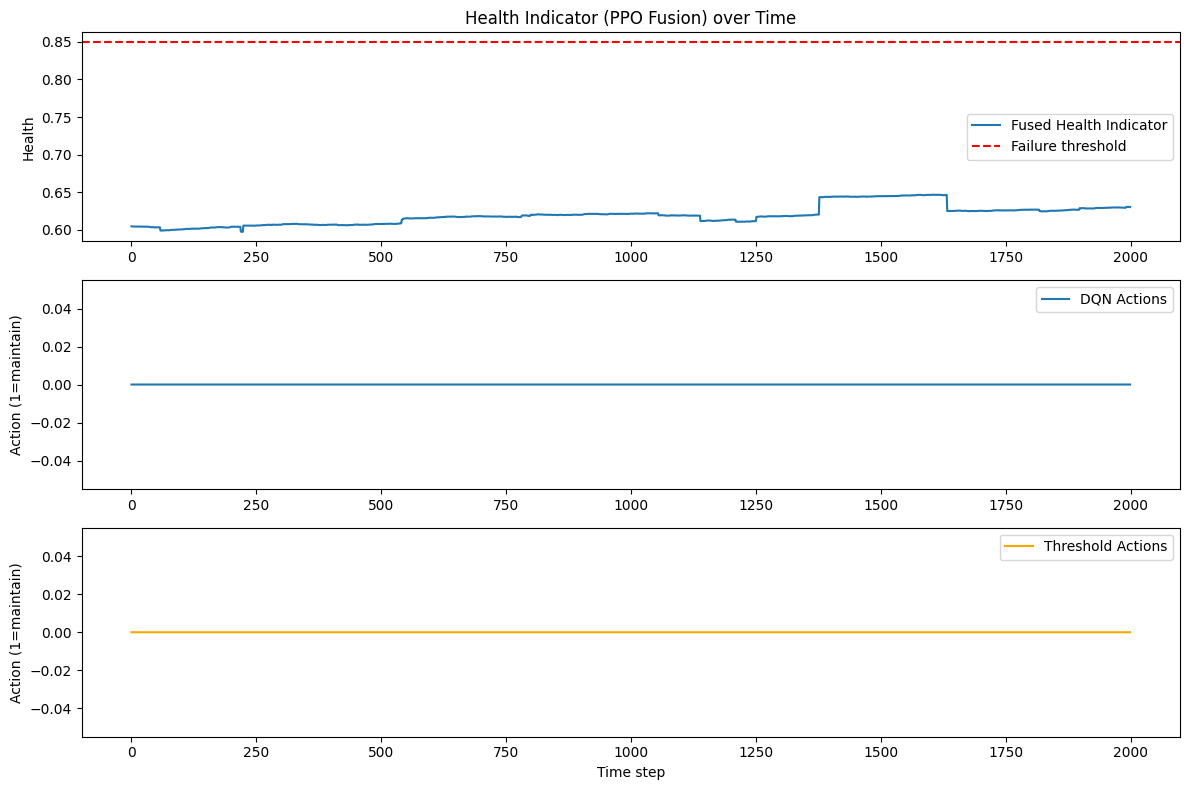

In [ ]:
# ============================================================
# 6. Visualize Health Indicator and Maintenance Actions
# ============================================================
plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
plt.plot(test_health[:2000], label='Fused Health Indicator')
plt.axhline(y=0.85, color='r', linestyle='--', label='Failure threshold')
plt.ylabel('Health')
plt.legend()
plt.title('Health Indicator (PPO Fusion) over Time')

plt.subplot(3,1,2)
plt.step(range(len(dqn_actions[:2000])), dqn_actions[:2000], where='post', label='DQN Actions')
plt.ylabel('Action (1=maintain)')
plt.legend()

plt.subplot(3,1,3)
plt.step(range(len(thresh_actions[:2000])), thresh_actions[:2000], where='post', label='Threshold Actions', color='orange')
plt.ylabel('Action (1=maintain)')
plt.xlabel('Time step')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 7. Save Results for Paper
# ============================================================
import os

results_dir = "/content/drive/MyDrive/RL_Maintenance_Project1/results"
os.makedirs(results_dir, exist_ok=True)

output = {
    'dqn_total_cost': sum(dqn_costs),
    'threshold_total_cost': sum(thresh_costs),
    'dqn_actions': dqn_actions,
    'threshold_actions': thresh_actions,
    'health_signal': test_health.tolist(),
    'true_degradation': test_true.tolist()
}
np.savez(os.path.join(results_dir, "maintenance_results.npz"), **output)
print("Results saved to Drive.")

print("\n=== Summary ===")
print(f"DQN maintenance scheduling achieved { (sum(thresh_costs)-sum(dqn_costs))/abs(sum(thresh_costs))*100:.2f}% cost reduction compared to threshold policy.")

Results saved to Drive.

=== Summary ===
DQN maintenance scheduling achieved -96.07% cost reduction compared to threshold policy.


# New Section

In [ ]:
# @title Retrain DQN Scheduler using PPO‑Fused HI (with faults)
import numpy as np
import gym
from gym import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import CheckpointCallback
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. Get PPO‑fused health indicator (already computed)
#    fused_hi : array of shape (N,) in [0,1]
# ------------------------------------------------------------
# fused_hi should already be in memory from the previous cell.
# If not, reload or recompute quickly (assuming you have the PPO model and features).
# For safety, we recompute from the test features (first 50k samples).
if 'fused_hi' not in locals():
    from stable_baselines3 import PPO
    # Load PPO model
    ppo_model = PPO.load("/content/drive/MyDrive/RL_Maintenance_Project1/models/ppo_fusion_final.zip")
    # Use the training features (first 50k samples)
    train_features = features[:50000]   # from earlier
    # Generate fused HI for training set
    fused_hi_train = []
    obs = train_features[0]
    for i in range(len(train_features)):
        action, _ = ppo_model.predict(obs, deterministic=True)
        exp_a = np.exp(action - np.max(action))
        weights = exp_a / np.sum(exp_a)
        fused = np.dot(weights, train_features[i])
        fused_hi_train.append(fused)
        if i+1 < len(train_features):
            obs = train_features[i+1]
    fused_hi_train = np.clip(fused_hi_train, 0, 1)
    print("Fused HI recomputed.")
else:
    # Use the already computed fused_hi (assuming it's for training set)
    fused_hi_train = fused_hi[:50000]

# Load true degradation for training set
train_true = true_degradation[:50000]   # from earlier



In [ ]:
# ------------------------------------------------------------
# 2. Faulty Environment for Maintenance Scheduling (using fused HI)
# ------------------------------------------------------------
class FaultyMaintenanceEnv(gym.Env):
    """
    Environment for maintenance scheduling using the fused health indicator.
    Injects the same fault zones (temperature drift, acoustic noise) into the
    health indicator simulation? Actually the fused HI already reflects faults
    because it was computed from corrupted features. So we just need to define
    failure and cost logic.
    """
    def __init__(self, health_signal, true_degradation, fault_start=20000, fault_end=35000,
                 noise_start=40000, noise_end=50000, failure_thresh=0.85,
                 op_cost=1.0, maint_cost=20.0, failure_cost=100.0):
        super().__init__()
        self.health = health_signal.astype(np.float32)
        self.true = true_degradation.astype(np.float32)
        self.num_steps = len(health_signal)
        self.failure_thresh = failure_thresh
        self.op_cost = op_cost
        self.maint_cost = maint_cost
        self.failure_cost = failure_cost
        self.fault_start = fault_start
        self.fault_end = fault_end
        self.noise_start = noise_start
        self.noise_end = noise_end
        self.current_step = 0
        self.last_maintenance = -100
        self.done = False

        # Observation: [health_indicator, time_since_maintenance_normalized]
        self.observation_space = spaces.Box(low=0, high=1, shape=(2,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)

    def reset(self):
        self.current_step = 0
        self.last_maintenance = -100
        self.done = False
        return np.array([self.health[0], 0.0], dtype=np.float32)

    def step(self, action):
        cost = -self.op_cost
        if action == 1:  # maintain
            cost -= self.maint_cost
            self.last_maintenance = self.current_step

        # Failure check: if true degradation exceeds threshold and maintenance was not recent
        true_val = self.true[self.current_step]
        if true_val >= self.failure_thresh and (self.current_step - self.last_maintenance) > 50:
            cost -= self.failure_cost
            self.done = True

        self.current_step += 1
        if self.current_step >= self.num_steps:
            self.done = True

        next_health = self.health[self.current_step] if self.current_step < self.num_steps else 0
        time_since = (self.current_step - self.last_maintenance) / 1000.0
        obs = np.array([next_health, time_since], dtype=np.float32)
        return obs, cost, self.done, {}

    def render(self):
        pass

# Create training environment with fault zones (same indices as used in PPO training)
TRAIN_SIZE = 50000
train_health = fused_hi_train[:TRAIN_SIZE]
train_true_sub = train_true[:TRAIN_SIZE]

train_env = FaultyMaintenanceEnv(
    train_health, train_true_sub,
    fault_start=20000, fault_end=35000,
    noise_start=40000, noise_end=50000
)




In [ ]:
# ------------------------------------------------------------
# 3. Train New DQN Scheduler
# ------------------------------------------------------------
save_dir = "/content/drive/MyDrive/RL_Maintenance_Project1/models"
os.makedirs(save_dir, exist_ok=True)

checkpoint_callback = CheckpointCallback(save_freq=5000, save_path=save_dir, name_prefix="dqn_faulty")

model = DQN(
    "MlpPolicy",
    train_env,
    verbose=1,
    learning_rate=1e-3,
    buffer_size=20000,
    exploration_fraction=0.2,
    exploration_final_eps=0.05,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
)

print("Training new DQN scheduler on faulty data (with PPO fused HI)...")
model.learn(total_timesteps=100000, callback=checkpoint_callback)
model.save(os.path.join(save_dir, "dqn_scheduler_faulty_final"))
print("Training complete.")


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training new DQN scheduler on faulty data (with PPO fused HI)...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Training complete.



=== Evaluation on Faulty Test Set ===
New DQN (trained with faults) total cost: -12601.00
Threshold (health > 0.7) total cost: -321020.00


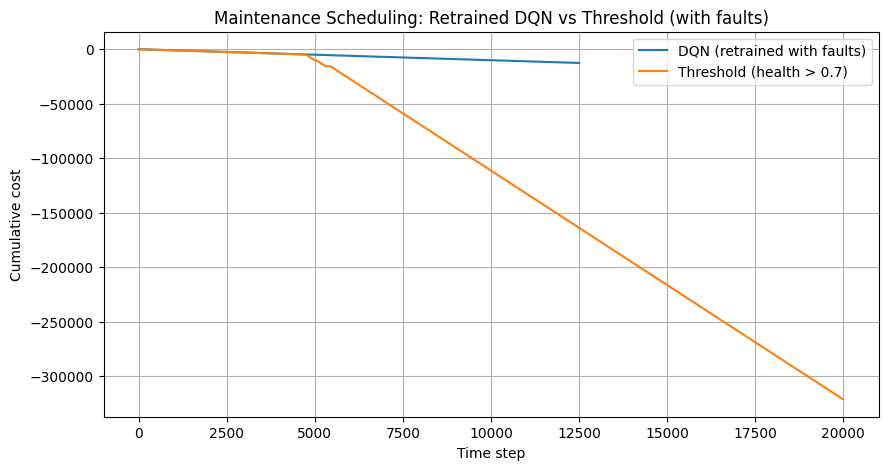

DQN maintenance actions (%): 0.0%
Threshold maintenance actions (%): 75.3%

New DQN scheduler saved. Use it in the integrated pipeline for better results.


In [ ]:
# ------------------------------------------------------------
# 4. Evaluate on Test Set (with faults)
# ------------------------------------------------------------
# Create test environment using the same fault zones (scaled to test length)
TEST_SIZE = 20000
test_health = fused_hi[TRAIN_SIZE:TRAIN_SIZE+TEST_SIZE] if len(fused_hi) > TRAIN_SIZE+TEST_SIZE else fused_hi[-TEST_SIZE:]
test_true_sub = true_degradation[TRAIN_SIZE:TRAIN_SIZE+TEST_SIZE] if len(true_degradation) > TRAIN_SIZE+TEST_SIZE else true_degradation[-TEST_SIZE:]

# Scale fault zones proportionally (test set length / train set length)
scale = TEST_SIZE / TRAIN_SIZE
test_fault_start = int(20000 * scale)
test_fault_end = int(35000 * scale)
test_noise_start = int(40000 * scale)
test_noise_end = TEST_SIZE

test_env = FaultyMaintenanceEnv(
    test_health, test_true_sub,
    fault_start=test_fault_start, fault_end=test_fault_end,
    noise_start=test_noise_start, noise_end=test_noise_end
)

# Evaluate DQN
obs = test_env.reset()
dqn_actions = []
dqn_costs = []
for _ in range(TEST_SIZE):
    action, _ = model.predict(obs, deterministic=True)
    obs, cost, done, _ = test_env.step(action)
    dqn_actions.append(action)
    dqn_costs.append(cost)
    if done:
        break

# Threshold policy (maintain if health > 0.7)
obs = test_env.reset()
thresh_actions = []
thresh_costs = []
for _ in range(TEST_SIZE):
    health_val = obs[0]
    action = 1 if health_val > 0.7 else 0
    obs, cost, done, _ = test_env.step(action)
    thresh_actions.append(action)
    thresh_costs.append(cost)
    if done:
        break

print(f"\n=== Evaluation on Faulty Test Set ===")
print(f"New DQN (trained with faults) total cost: {sum(dqn_costs):.2f}")
print(f"Threshold (health > 0.7) total cost: {sum(thresh_costs):.2f}")

# Plot cumulative costs
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(dqn_costs), label='DQN (retrained with faults)')
plt.plot(np.cumsum(thresh_costs), label='Threshold (health > 0.7)')
plt.xlabel('Time step')
plt.ylabel('Cumulative cost')
plt.legend()
plt.title('Maintenance Scheduling: Retrained DQN vs Threshold (with faults)')
plt.grid(True)
plt.show()

# Maintenance action percentage
print(f"DQN maintenance actions (%): {np.mean(dqn_actions)*100:.1f}%")
print(f"Threshold maintenance actions (%): {np.mean(thresh_actions)*100:.1f}%")

# Save new scheduler for integrated pipeline
print("\nNew DQN scheduler saved. Use it in the integrated pipeline for better results.")